In [1]:
import pandas as pd
import quantstats as qs
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
dados_empresas = pd.read_csv("dados_empresas.csv")
dados_empresas["retorno"] = dados_empresas.groupby("ticker")["preco_fechamento_ajustado"].pct_change()
dados_empresas["retorno"] = dados_empresas.groupby("ticker")["retorno"].shift(-1)
dados_empresas = dados_empresas[dados_empresas["volume_negociado"] > 1000000]
dados_empresas['ranking_ev_ebit'] = dados_empresas.groupby('data')['ebit_ev'].rank(ascending = False)
dados_empresas['ranking_roic'] = dados_empresas.groupby('data')['roic'].rank(ascending = False)
dados_empresas['ranking_final'] = dados_empresas['ranking_ev_ebit'] + dados_empresas['ranking_roic']
dados_empresas['ranking_final'] = dados_empresas.groupby('data')['ranking_final'].rank()
dados_empresas[dados_empresas['data'] == '2017-06-30'].sort_values('ranking_final').head(20)
dados_empresas = dados_empresas[dados_empresas['ranking_final'] <= 10]
dados_empresas

,data,ticker,preco_fechamento_ajustado,volume_negociado,ebit_ev,roic,retorno,ranking_ev_ebit,ranking_roic,ranking_final
563,2016-07-31,AGRO3,7.08,1367216.0,0.222828,0.154424,-0.052260,2.0,18.0,5.5
588,2018-08-31,AGRO3,8.65,1686357.0,0.163671,0.130726,-0.053179,8.0,32.0,10.0
593,2019-01-31,AGRO3,10.16,1254681.0,0.251466,0.210253,-0.013780,3.0,9.0,4.0
595,2019-03-31,AGRO3,9.83,8890526.0,0.252551,0.207867,-0.003052,2.0,7.0,2.0
598,2019-06-30,AGRO3,10.49,5485742.0,0.173807,0.152416,0.005720,9.0,22.0,5.0
...,...,...,...,...,...,...,...,...,...,...
50001,2024-02-29,WIZC3,6.02,2185709.0,0.355313,0.227289,0.166113,4.0,7.0,1.0
50002,2024-03-31,WIZC3,7.02,21525465.0,0.363341,0.217309,-0.011396,4.0,15.0,3.0
50003,2024-04-30,WIZC3,6.94,3375745.0,0.378248,0.217309,-0.142651,4.0,14.0,2.0
50004,2024-05-31,WIZC3,5.95,2538401.0,0.520612,0.225720,-0.040336,2.0,12.0,2.0


In [3]:
rentabilidade_por_carteiras = dados_empresas.groupby('data')['retorno'].mean()
rentabilidade_por_carteiras = rentabilidade_por_carteiras.to_frame()

rentabilidade_por_carteiras

,retorno
data,
2012-12-31,-0.052051
2013-01-31,0.019020
2013-02-28,0.011480
2013-03-31,0.047786
2013-04-30,0.018336
...,...
2024-02-29,-0.017760
2024-03-31,-0.038745
2024-04-30,-0.027068


In [4]:
rentabilidade_por_carteiras['Magic Formula'] = (rentabilidade_por_carteiras['retorno'] + 1).cumprod() - 1

rentabilidade_por_carteiras = rentabilidade_por_carteiras.shift(1)

rentabilidade_por_carteiras = rentabilidade_por_carteiras.dropna()

In [5]:
ibov = pd.read_csv('ibov.csv')

retornos_ibov = ibov['fechamento'].pct_change().dropna()
retorno_acum_ibov = (1 + retornos_ibov).cumprod() - 1
rentabilidade_por_carteiras['Ibovespa'] = retorno_acum_ibov.values
rentabilidade_por_carteiras = rentabilidade_por_carteiras.drop('retorno', axis = 1)

In [6]:
qs.extend_pandas()

In [7]:
rentabilidade_por_carteiras.index = pd.to_datetime(rentabilidade_por_carteiras.index)

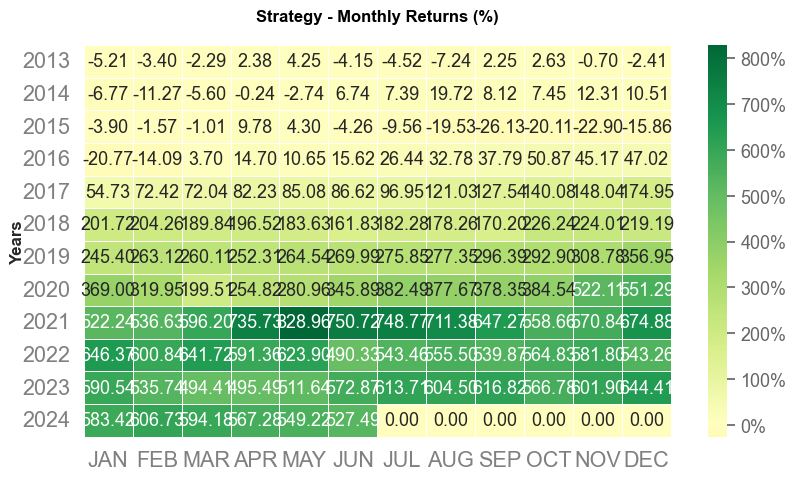

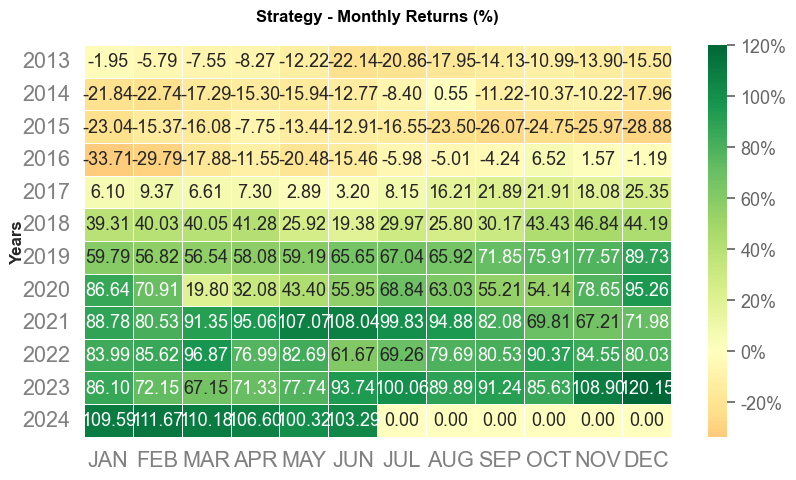

In [8]:
rentabilidade_por_carteiras['Magic Formula'].plot_monthly_heatmap()
rentabilidade_por_carteiras['Ibovespa'].plot_monthly_heatmap()

<Axes: xlabel='data'>

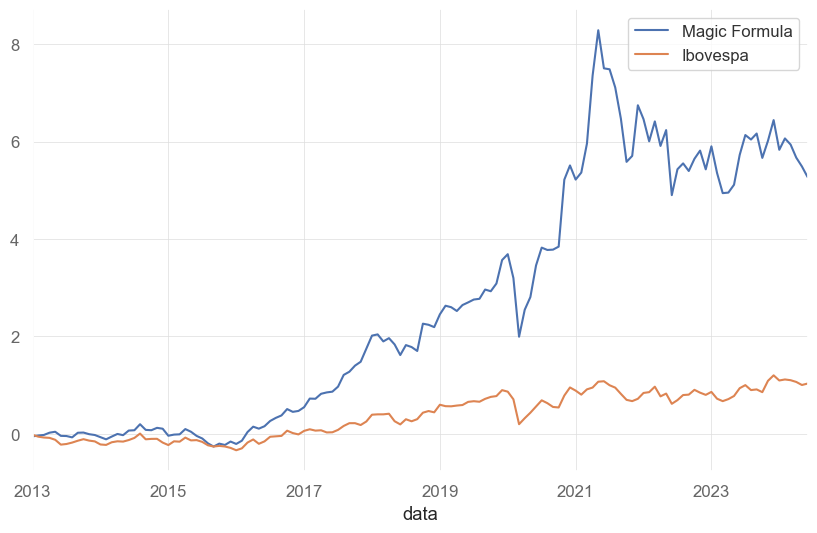

In [9]:
rentabilidade_por_carteiras.plot()

In [10]:
plt.ioff

<function matplotlib.pyplot.ioff() -> 'AbstractContextManager'>

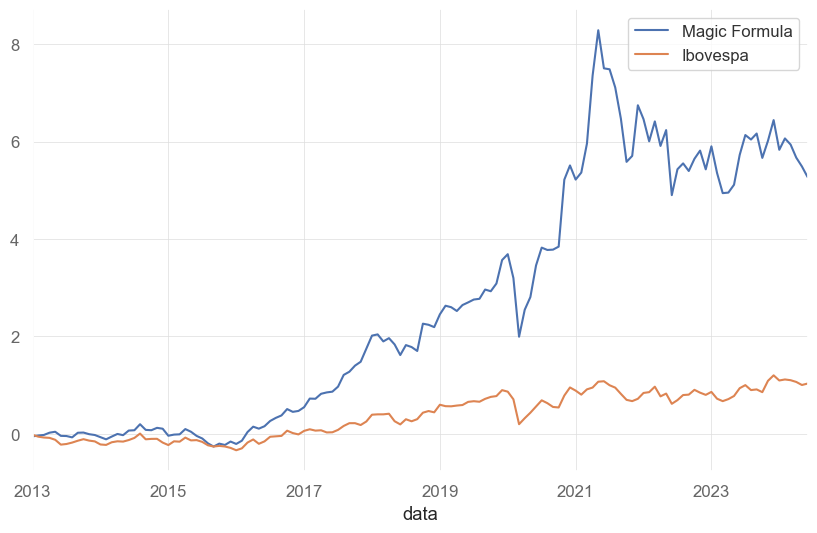

In [11]:
rentabilidade_por_carteiras.plot();

plt.show()